In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
csv_path = "final_3tier_dataset.csv"
print(f"Loading dataset: {csv_path}...")
df = pd.read_csv(csv_path)

Loading dataset: final_3tier_dataset.csv...


In [3]:
X = df[['Brightness', 'Blurriness', 'SNR']]
y = df['Class_Label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training on {len(X_train)} images, Testing on {len(X_test)} images...\n")

Training on 5988 images, Testing on 1497 images...



In [4]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [5]:
predictions = model.predict(X_test)

print("--- Model Accuracy Report ---")
# zero_division=0 prevents warnings if some classes are too small to have test data
print(classification_report(y_test, predictions, zero_division=0))

--- Model Accuracy Report ---
                                          precision    recall  f1-score   support

       high_light_heavy_blur_heavy_noise       1.00      1.00      1.00       142
         high_light_heavy_blur_low_noise       1.00      1.00      1.00        14
     high_light_heavy_blur_perfect_noise       1.00      0.97      0.99        34
         high_light_low_blur_heavy_noise       1.00      1.00      1.00        17
     high_light_perfect_blur_heavy_noise       0.99      0.99      0.99       202
       high_light_perfect_blur_low_noise       1.00      0.94      0.97        36
   high_light_perfect_blur_perfect_noise       0.99      1.00      1.00       111
          low_light_heavy_blur_low_noise       1.00      1.00      1.00        36
      low_light_heavy_blur_perfect_noise       0.99      0.99      0.99       138
        low_light_low_blur_perfect_noise       1.00      1.00      1.00        15
      low_light_perfect_blur_heavy_noise       0.00      0.00      

In [6]:
importance = model.feature_importances_
print("\n--- Feature Importance ---")
print(f"Brightness: {importance[0]*100:.2f}%")
print(f"Blurriness: {importance[1]*100:.2f}%")
print(f"SNR:        {importance[2]*100:.2f}%")


--- Feature Importance ---
Brightness: 32.27%
Blurriness: 29.99%
SNR:        37.74%


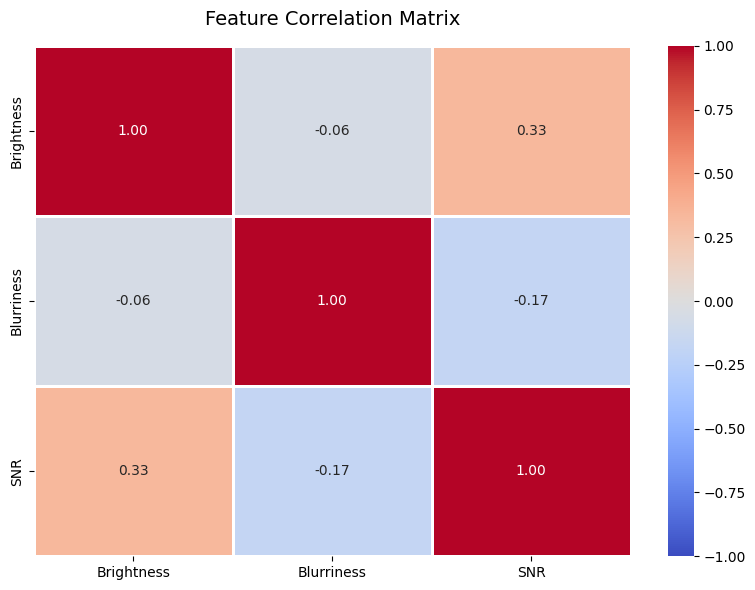

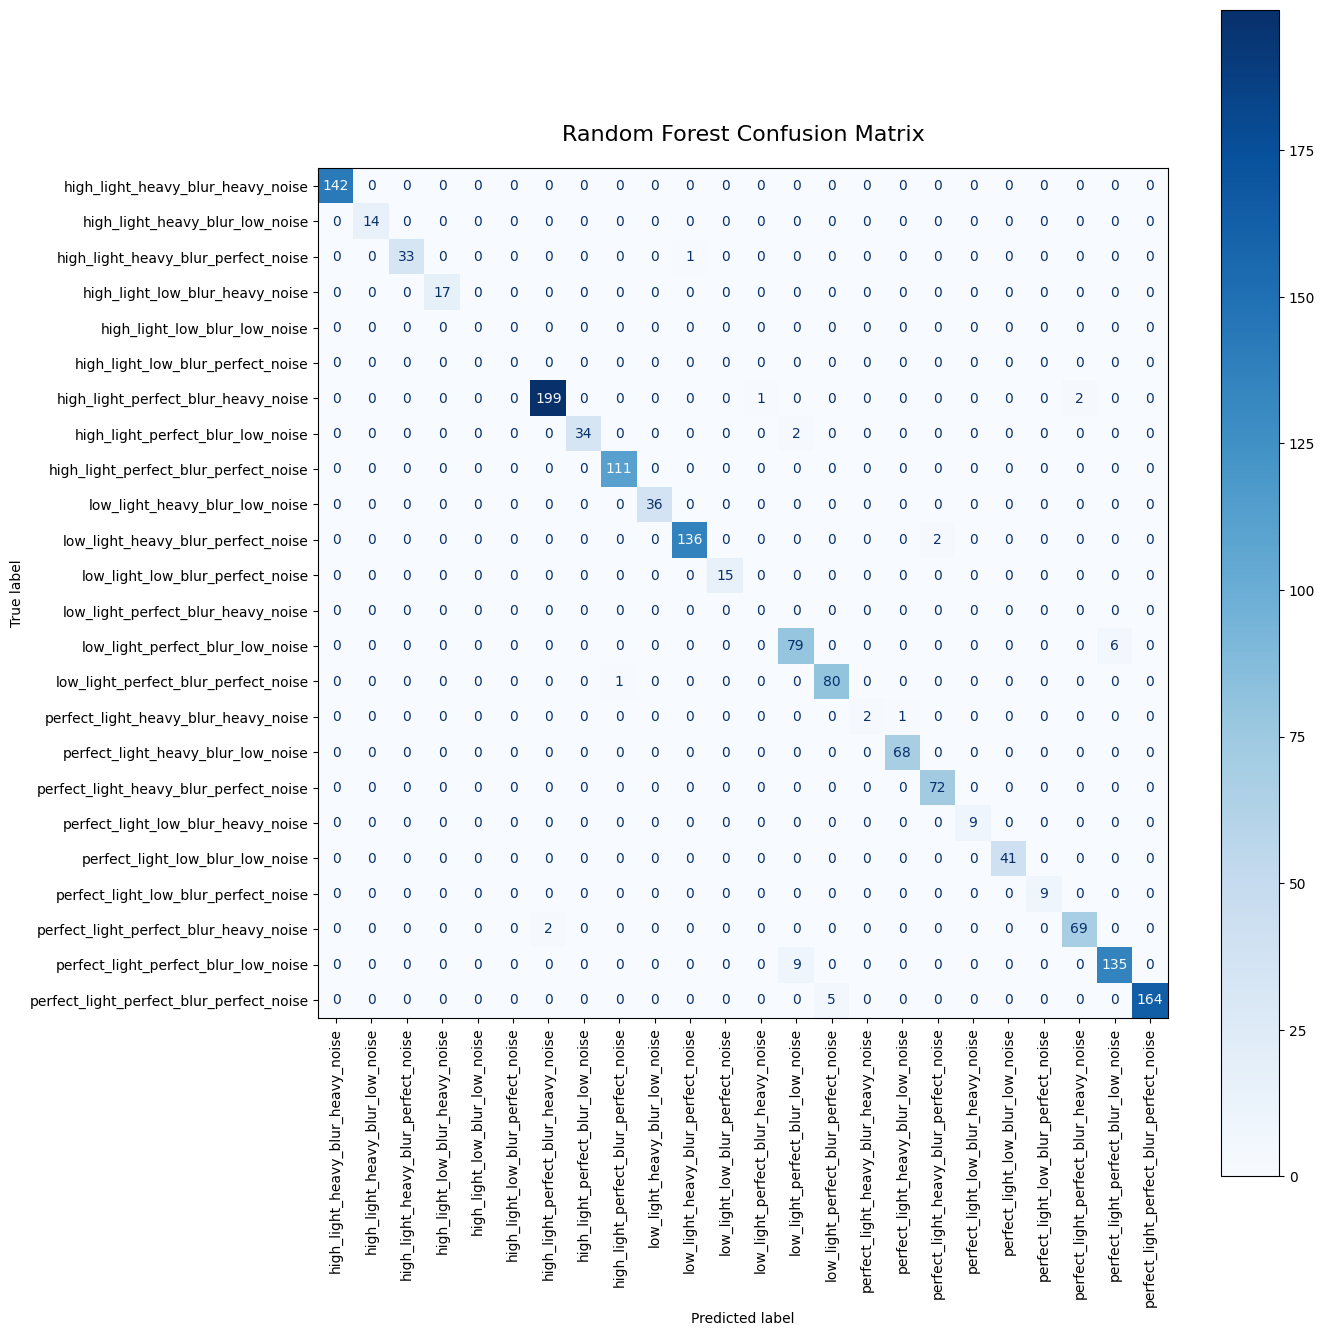

In [9]:
plt.figure(figsize=(8, 6))

features_df = df[['Brightness', 'Blurriness', 'SNR']]
corr_matrix = features_df.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=1, vmin=-1, vmax=1)
plt.title("Feature Correlation Matrix", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(14, 14))

cm = confusion_matrix(y_test, predictions, labels=model.classes_)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)

disp.plot(cmap='Blues', ax=ax, xticks_rotation='vertical')
plt.title("Random Forest Confusion Matrix", fontsize=16, pad=20)
plt.tight_layout()
plt.show()